# Useful libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')

AIRPORTS = ['Ajaccio', 'Bastia', 'Bron', 'Nantes', 'Biarritz', 'Pise']
AIRPORT_COORDS = {
    'Bron':    (4.9389,  45.7294),
    'Bastia':  (9.4837,  42.5527),
    'Ajaccio': (8.8029,  41.9236),
    'Nantes':  (-1.6107, 47.1532),
    'Pise':    (10.399,  43.695),
    'Biarritz':(-1.524,  43.4683),
}
print('✅ Imports OK')

✅ Imports OK


In [2]:
import joblib
path = '..\\data\\meteo_data.pkl'
meteo_data = joblib.load(path)

In [3]:
dictio = pd.read_csv("..\\data\\variables_description.csv")
dictio.index = dictio['variable']
#dictio

In [4]:
df = meteo_data['df']
VAR = meteo_data['VAR']
dummies_vars = meteo_data['dumies_vars']
selected_features = meteo_data['df']
IDS = meteo_data['IDS']
TARGET = meteo_data['TARGET']

In [5]:
df["mois_annee"] = df["date"].dt.strftime("%Y-%m")
df['next_10min_cg20'] = df['time_to_next_cg20'] > (10 * 60) # LE prochain arrive dans moins de 10 minutes


In [ ]:
df["mois_annee"] = df["date"].dt.strftime("%Y-%m")
df['next_30min_cg20'] = df['time_to_next_cg20'] > (30 * 60) # LE prochain arrive après 30 minutes
df['next_30min_cg20'].value_counts()

next_30min_cg20
False    455410
True      51624
Name: count, dtype: int64

## Séparation en train, test et OOT

Le developpement du score se fera sur une période : entre **2019--2021** et **2022** la validation hors temps




In [7]:
from sklearn.model_selection import train_test_split
target_col = 'next_30min_cg20'
data = df
# Combine the two columns for stratification
dev_mask = (df['year'] >= 2015) & (df['year'] <= 2020)
stratify_col = (data[target_col].astype(str) + "_" + data['month'].astype(str))[dev_mask]
train_data, test_data = train_test_split(
	data[dev_mask], 
	test_size=0.3, 
	random_state=42, 
	stratify=stratify_col
)
train_data, test_data = train_data.reset_index(drop=True), test_data.reset_index(drop=True)
oot_data = data[data['year'] >= 2021].reset_index(drop=True)
train_data.shape, test_data.shape, oot_data.shape

((273749, 104), (117321, 104), (115964, 104))

In [8]:
train_data.shape, test_data.shape, oot_data.shape

((273749, 104), (117321, 104), (115964, 104))

# Prediction

In [9]:
import joblib
import sys
import os
from importlib import reload
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

pkg = joblib.load("..\models\logit_30min_package.pkl")
logit_model = pkg["model"]
impute_map = pkg["impute_map"]
final_vars = list(pkg["feature_names"])
const = pkg["const"]
df_summary = pkg["df_summary"]

from src import predictor
from importlib import reload
reload(predictor)
pred = predictor.Predictor(VAR=final_vars,impute_map=impute_map,df_summary=df_summary,const=const)


## jeux test

In [11]:
from sklearn.metrics import roc_auc_score
df = pred.prepare_data(test_data)
test_data['probas'] = pred.predire_probas(df)
test_data['points'] = pred.predire_points1000(df)
y_score = test_data["probas"].astype(float).values
y_true = test_data[target_col].astype(int).values  
auc = roc_auc_score(y_true, y_score)
print(f"gini : {2*auc-1}")

gini : 0.791063225568281


## jeux ooT

In [12]:
from sklearn.metrics import roc_auc_score
df = pred.prepare_data(oot_data)
oot_data['probas'] = pred.predire_probas(df)
oot_data['points'] = pred.predire_points1000(df)
y_score = oot_data["probas"].astype(float).values
y_true = oot_data[target_col].astype(int).values  
auc = roc_auc_score(y_true, y_score)
print(f"gini : {2*auc-1}")

gini : 0.7932059057990049


## jeux train

In [13]:
from sklearn.metrics import roc_auc_score
dt = pred.prepare_data(train_data)
train_data['probas'] = pred.predire_probas(dt)
train_data['points'] = pred.predire_points1000(dt)
y_score = train_data["probas"].astype(float).values
y_true = train_data[target_col].astype(int).values  
auc = roc_auc_score(y_true, y_score)
print(f"gini : {2*auc-1}")

gini : 0.7915007007261154


# Analyse des performances

In [37]:
from src import analyser
from importlib import reload
reload(analyser)
train_analyser= analyser.Analyser(X=train_data,target_col=target_col)
test_analyser= analyser.Analyser(X=test_data,target_col=target_col)
oot_analyser= analyser.Analyser(X=oot_data,target_col=target_col)

## AUC

GINI : 0.7911 --> Très bon — bonne capacité discriminative pour la plupart des usages.


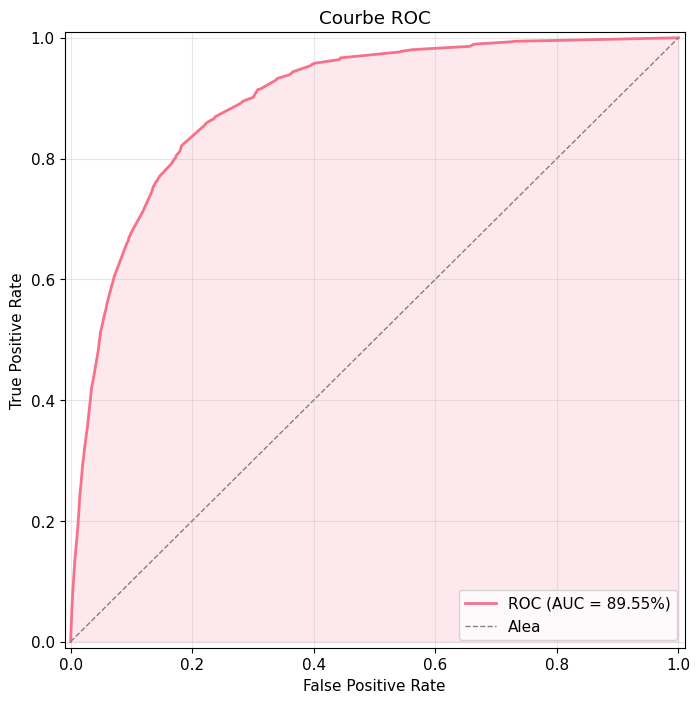

GINI : 0.7932 --> Très bon — bonne capacité discriminative pour la plupart des usages.


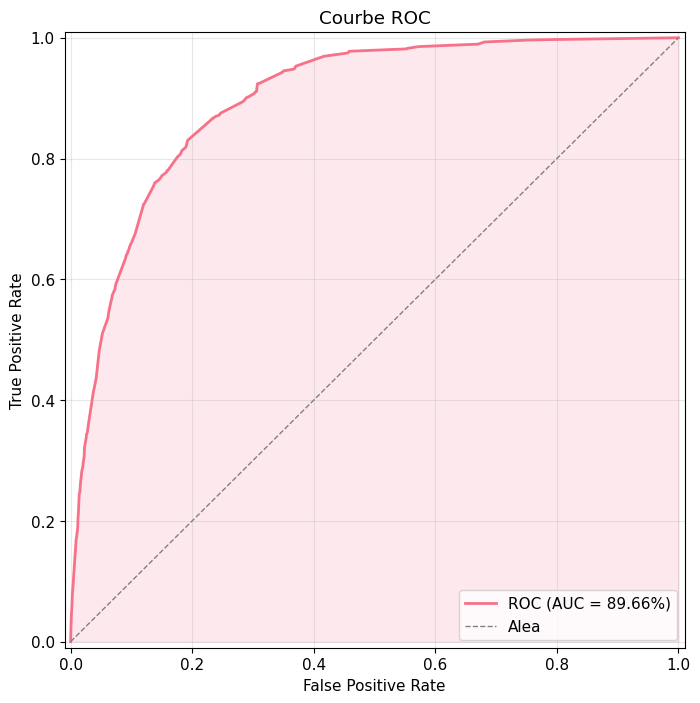

In [17]:
test_analyser.plot_ROC_AUC()
oot_analyser.plot_ROC_AUC()

## AUC PR

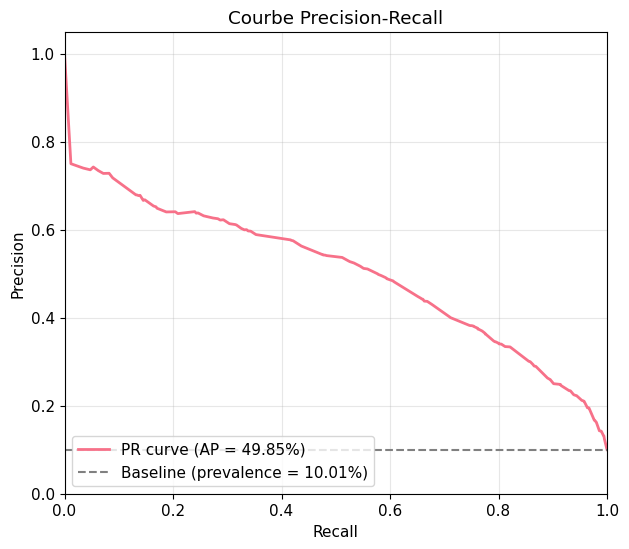

AUC PR: 49.85%
Ratio de performance: 4.98
Interprétation: Fort gain relatif pour des actions ciblées.


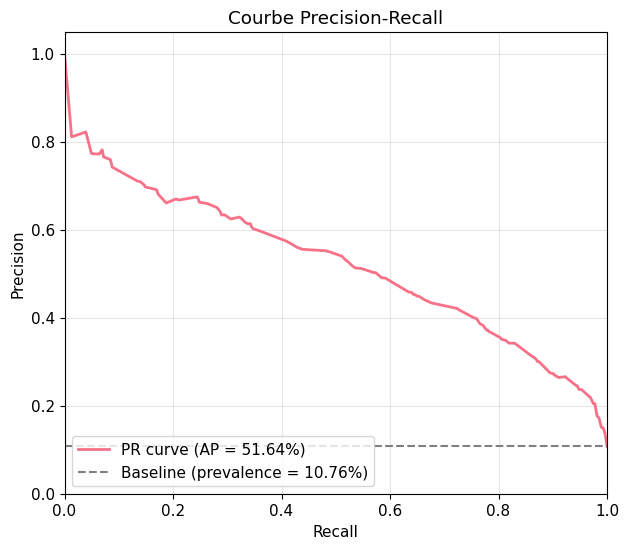

AUC PR: 51.64%
Ratio de performance: 4.80
Interprétation: Fort gain relatif pour des actions ciblées.


In [18]:
test_analyser.plot_PR_AUC()
oot_analyser.plot_PR_AUC()

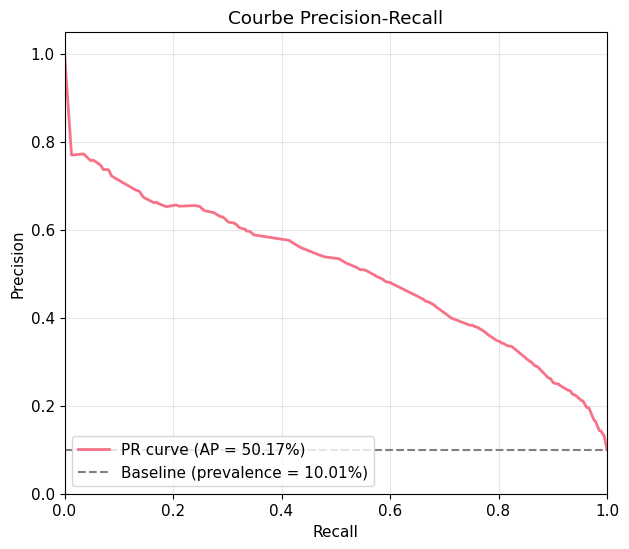

AUC PR: 50.17%
Ratio de performance: 5.01
Interprétation: Fort gain relatif pour des actions ciblées.


In [19]:
train_analyser.plot_PR_AUC()

# AUC maské

In [44]:
from sklearn.metrics import roc_auc_score, average_precision_score

def eval_on_mask(df, mask, y_col, proba_col):
    """
    Calcule GINI, ROC AUC et Ratio RP (PR AUC / prevalence) sur un sous-ensemble du DataFrame.

    Paramètres
    ----------
    df        : DataFrame complet
    mask      : condition booléenne, ex: df['airport'] == 'PAU'
    y_col     : nom de la colonne cible (0/1)
    proba_col : nom de la colonne de probabilités prédites

    Retourne
    --------
    dict avec les métriques
    """
    subset = df[mask]

    if len(subset) == 0:
        print("Masque vide — aucune ligne ne vérifie la condition.")
        return None

    y     = subset[y_col]
    proba = subset[proba_col]

    if y.nunique() < 2:
        print(f"Une seule classe présente dans le sous-ensemble ({len(subset)} lignes) — AUC indéfinie.")
        return None

    prevalence  = y.mean()
    auc         = roc_auc_score(y, proba)
    gini        = 2 * auc - 1
    auc_pr      = average_precision_score(y, proba)
    rp          = auc_pr / prevalence

    # print(f"Sous-ensemble : {len(subset)} lignes  |  Prevalence : {prevalence:.3%}")
    # print(f"ROC AUC : {auc:.4f}  |  Gini : {gini:.4f}")
    # print(f"PR AUC  : {auc_pr:.4f}  |  Ratio RP : {rp:.4f}")

    return {"n": len(subset), "prevalence": prevalence,
            "auc": auc, "gini": gini, "auc_pr": auc_pr, "rp": rp}


## par aeroport

In [49]:
def auc_mask(train_data,col = "airport"):
    results = []
    for airport in train_data[col].unique():
        mask = train_data[col] == airport
        metrics = eval_on_mask(train_data, mask=mask, y_col=target_col, proba_col='probas')
        if metrics:
            metrics[col] = airport
            results.append(metrics)

    df_results = (pd.DataFrame(results)
                    .set_index(col)
                    [['n', 'prevalence', 'auc', 'gini', 'auc_pr', 'rp']]
                    .sort_values('rp', ascending=False))
    return df_results
    # df_results.style.format({
    #     'prevalence': '{:.2%}',
    #     'auc':        '{:.4f}',
    #     'gini':       '{:.4f}',
    #     'auc_pr':     '{:.4f}',
    #     'rp':         '{:.2f}',
    # }).background_gradient(subset=['auc', 'gini', 'rp'], cmap='RdYlGn')


In [50]:
auc_mask(train_data)

,n,prevalence,auc,gini,auc_pr,rp
airport,,,,,,
Nantes,18700,0.088984,0.907613,0.815226,0.513301,5.768469
Bastia,67898,0.097264,0.895476,0.790952,0.492250,5.060987
Ajaccio,37765,0.097233,0.897841,0.795681,0.491107,5.050827
Pise,86064,0.107722,0.906739,0.813479,0.538337,4.997459
Biarritz,63322,0.097849,0.878736,0.757472,0.475938,4.864000


In [ ]:
auc_mask(test_data)

,n,prevalence,auc,gini,auc_pr,rp
airport,,,,,,
Nantes,8237,0.091417,0.900030,0.800060,0.487748,5.335436
Biarritz,27049,0.098303,0.887257,0.774514,0.500521,5.091606
Pise,36719,0.106893,0.908399,0.816797,0.539135,5.043695
Bastia,29093,0.095624,0.890235,0.780469,0.480481,5.024669
Ajaccio,16223,0.100228,0.888829,0.777658,0.464770,4.637124


In [ ]:
auc_mask(oot_data)

,n,prevalence,auc,gini,auc_pr,rp
airport,,,,,,
Bastia,28926,0.101397,0.922154,0.844307,0.536655,5.292626
Pise,33930,0.117330,0.892916,0.785833,0.567204,4.834271
Nantes,9791,0.111837,0.898869,0.797737,0.534936,4.783155
Ajaccio,18512,0.111387,0.908119,0.816238,0.524814,4.711621
Biarritz,24805,0.096795,0.865175,0.730350,0.425975,4.400800


## par saison

In [51]:
auc_mask(train_data,col = 'season')

,n,prevalence,auc,gini,auc_pr,rp
season,,,,,,
Automne,78961,0.085751,0.908065,0.816130,0.488223,5.693484
Été,160922,0.087459,0.900157,0.800313,0.487003,5.568385
Printemps,27421,0.180300,0.840881,0.681762,0.541600,3.003888
Hiver,6445,0.251047,0.831206,0.662412,0.600430,2.391699


In [53]:
auc_mask(test_data,col = 'season')

,n,prevalence,auc,gini,auc_pr,rp
season,,,,,,
Automne,33838,0.085732,0.908345,0.816689,0.489453,5.709108
Été,68966,0.087449,0.899036,0.798071,0.483080,5.524143
Printemps,11753,0.180294,0.840812,0.681623,0.533031,2.956449
Hiver,2764,0.251085,0.837052,0.674104,0.597101,2.378078


In [54]:
auc_mask(oot_data,col = 'season')

,n,prevalence,auc,gini,auc_pr,rp
season,,,,,,
Automne,38851,0.081928,0.935678,0.871357,0.629285,7.680918
Printemps,15821,0.078946,0.929911,0.859821,0.578795,7.331555
Été,58641,0.127982,0.858807,0.717614,0.452218,3.533447
Hiver,2651,0.201811,0.874473,0.748945,0.620035,3.072358


## Partial AUC

GINI : 0.7911 --> Très bon — bonne capacité discriminative pour la plupart des usages.


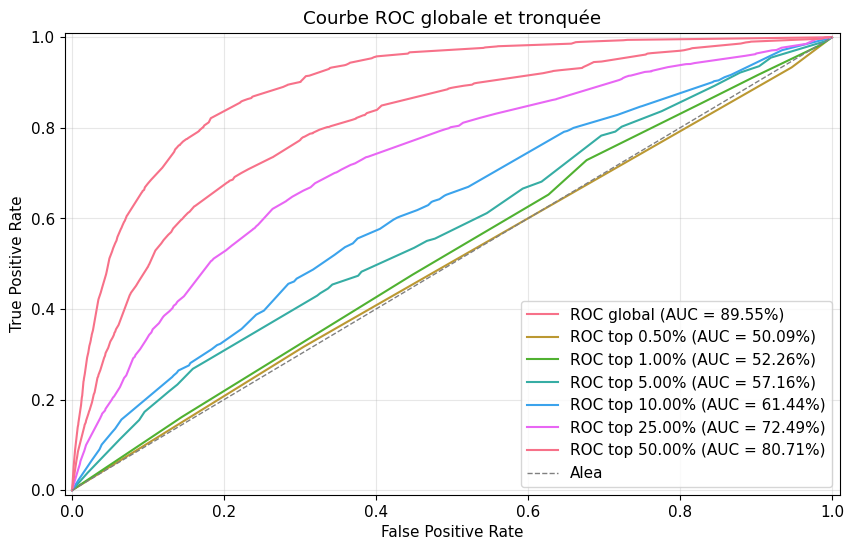

GINI : 0.7932 --> Très bon — bonne capacité discriminative pour la plupart des usages.


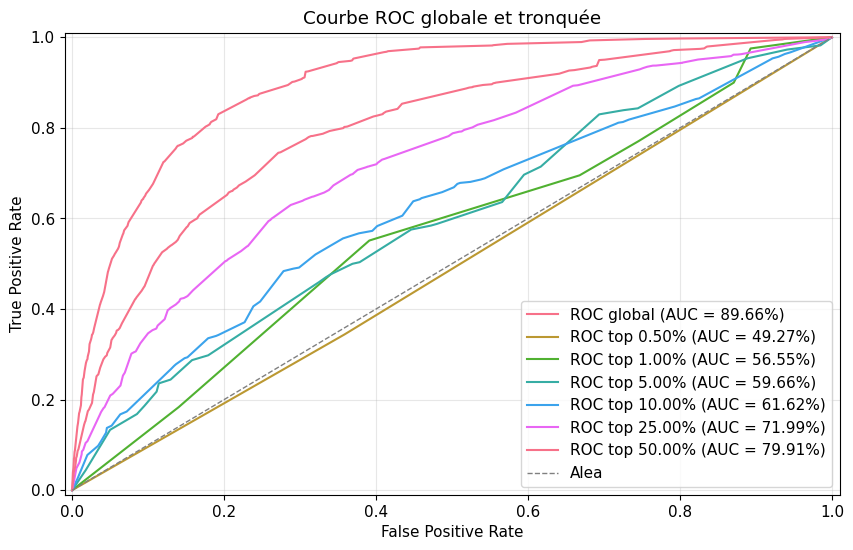

In [20]:
percent = [0.005, 0.01, 0.05, 0.1, 0.25, 0.5]
test_analyser.plot_ROC_AUC_global_partial(percents=percent)
oot_analyser.plot_ROC_AUC_global_partial(percents=percent)

## KS stat

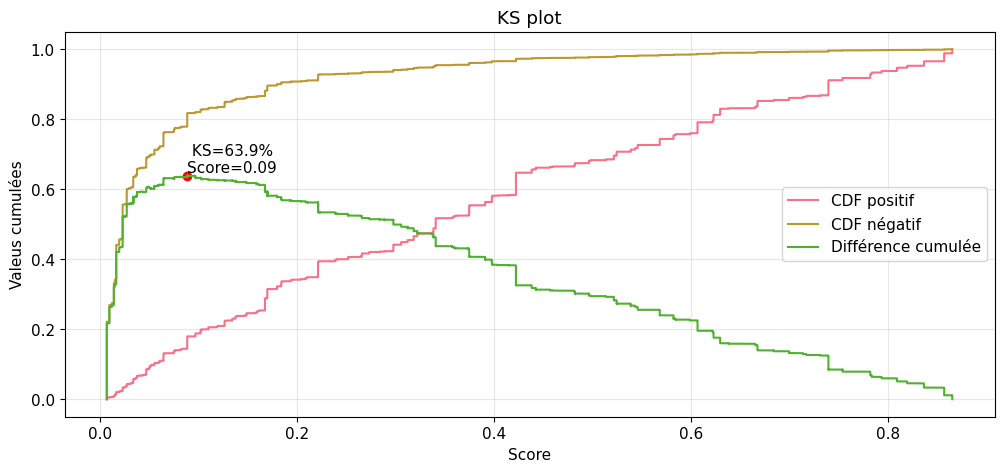

Discrimination correcte (40% < KS < 70%)


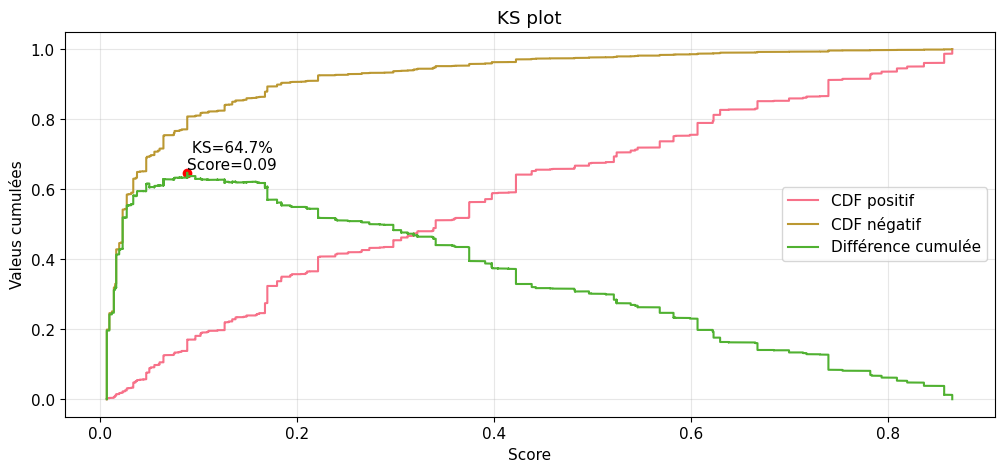

Discrimination correcte (40% < KS < 70%)


In [21]:
test_analyser.plot_ks()
oot_analyser.plot_ks()

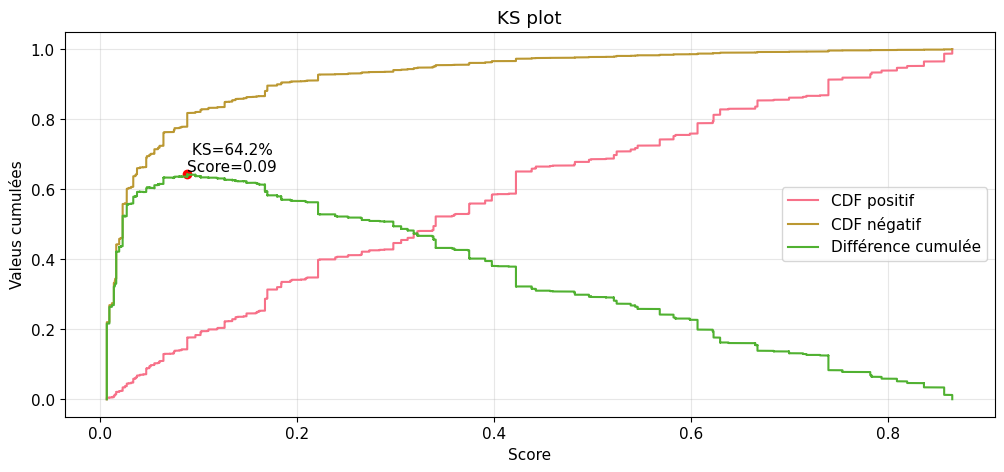

Discrimination correcte (40% < KS < 70%)


In [22]:
train_analyser.plot_ks()

## Reliability diagrams

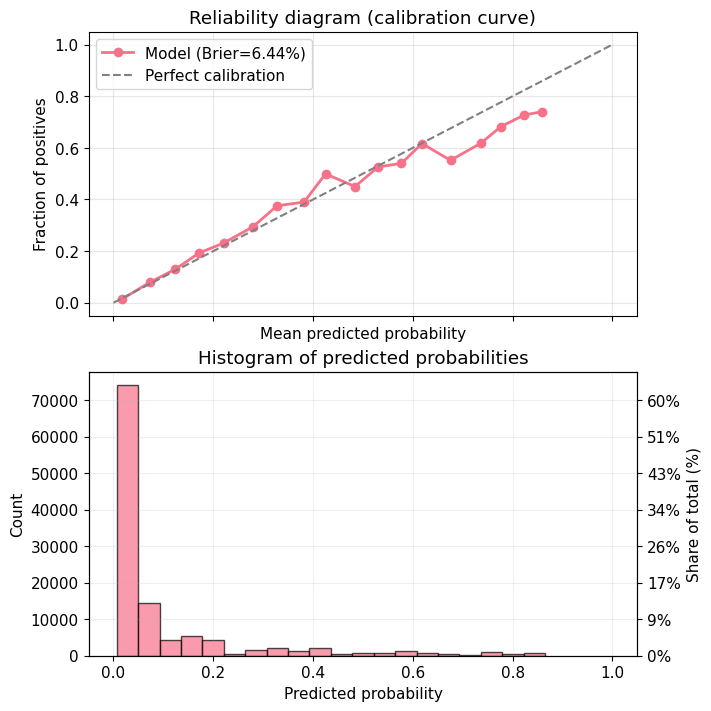

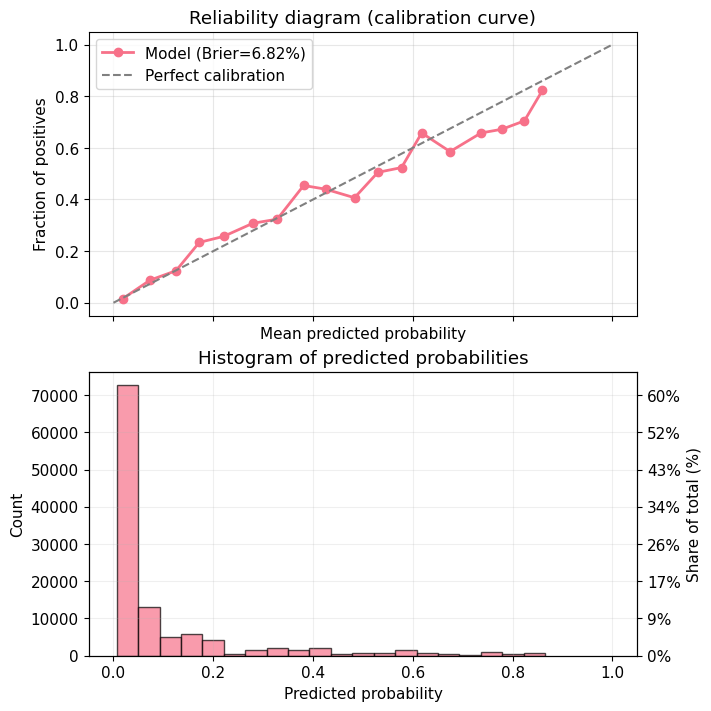

In [23]:
test_analyser.reliability_diagram()
oot_analyser.reliability_diagram()

## quelques plots

Text(0.5, 1.0, 'Distribution of probability scores by default status')

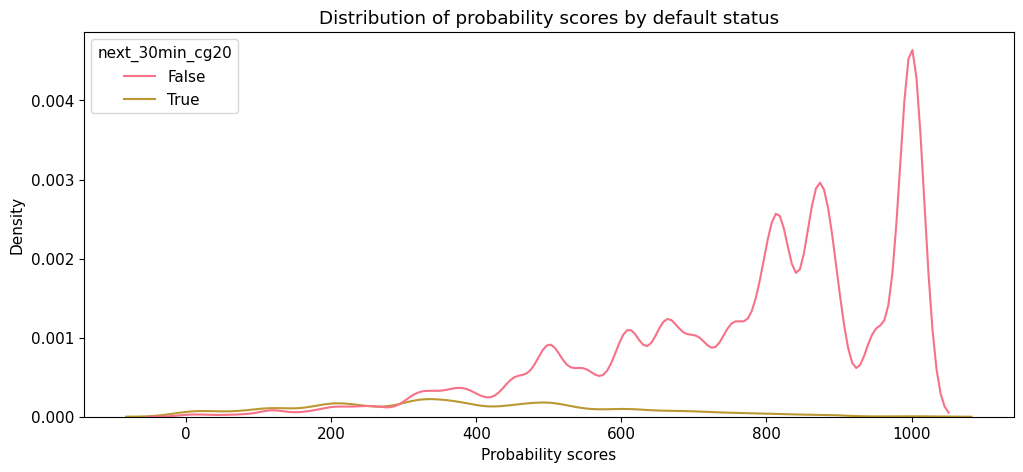

In [25]:
sns.kdeplot(data=train_data, x='points', hue=target_col)
plt.xlabel("Probability scores")
plt.ylabel("Density")
plt.title("Distribution of probability scores by default status")

Text(0.5, 1.0, 'Distribution of probability scores by default status')

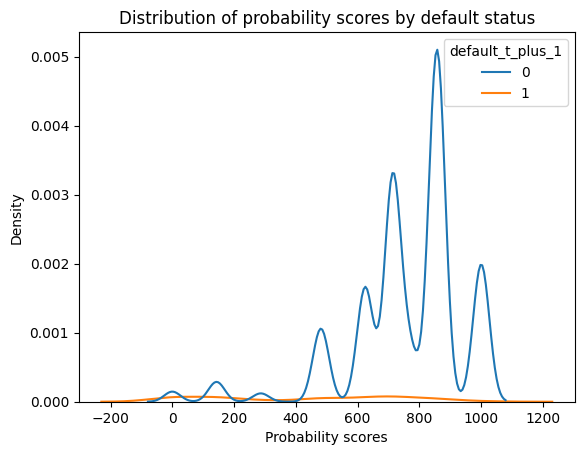

In [87]:
sns.kdeplot(data=test_data, x='points', hue='default_t_plus_1')
plt.xlabel("Probability scores")
plt.ylabel("Density")
plt.title("Distribution of probability scores by default status")

Text(0.5, 1.0, 'Probability scores distribution by default status')

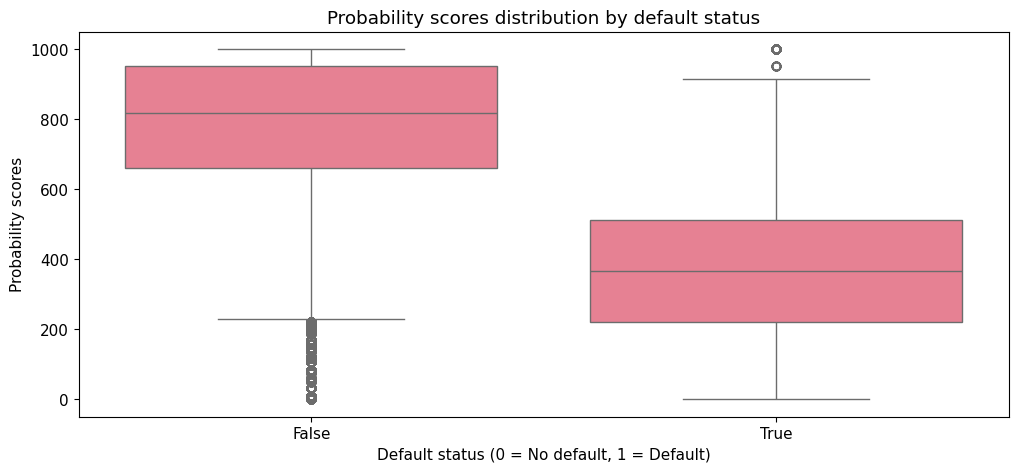

In [27]:
sns.boxplot(data=train_data, x=target_col, y='points')
plt.xlabel("Default status (0 = No default, 1 = Default)")
plt.ylabel("Probability scores")
plt.title("Probability scores distribution by default status")

In [30]:
def construire_part_df(df, score_col='points', label_col='default_t_plus_1', rnd=0, pas=-1):
    """
    Constructs a dataframe of good/bad proportions by score interval.
    
    df : input dataframe
    score_col : name of the score column
    label_col : column containing default indicator (0/1)
    pas : grouping step for scores (e.g., 20 points)
    """
    
    # 1. Create rounded column
    df = df[[score_col, label_col]].copy()
    if pas==-1:
        df["score_round"] =df[score_col]# 
    else : 
        df["score_round"] = (df[score_col] / pas).round(rnd) * pas
        df["score_round"] = df["score_round"].astype(int)
    
    # 2. Calculate total counts and counts by class
    part_df = df.groupby("score_round").agg(
        nb_total    = (label_col, "size"),
        nb_non_default = (label_col, lambda x: (x == 0).sum()),  # Assuming 0 = no default
        nb_default      = (label_col, lambda x: (x == 1).sum())   # Assuming 1 = default
    ).reset_index()
    
    # 3. Calculate proportions
    part_df["non_default"] = part_df["nb_non_default"] / part_df["nb_total"]
    part_df["default"]  = part_df["nb_default"] / part_df["nb_total"]
    
    return part_df

def score_graph_empile(df, score_col='points', label_col='default_t_plus_1', rnd=0, pas=20):
    """
    Creates a stacked bar chart of default vs non-default by score interval.
    Displays default rate on each bar.
    """
    # Build the distribution dataframe
    part_df = construire_part_df(df, score_col, label_col, rnd=rnd, pas=pas)
    
    # Calculate default rate for each interval
    part_df['default_rate'] = part_df['default'] / (part_df['non_default'] + part_df['default'])
    
    # Create the chart
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Plot stacked bars
    bars = part_df[['non_default', 'default']].plot(
        ax=ax,
        kind='bar',
        stacked=True,
        legend=False,
        color=['#2ecc71', '#e74c3c'],  # Green for non-default, red for default
        width=0.7
    )
    
    # Add legend
    ax.legend(['Non-default', 'Default'], loc='upper left', bbox_to_anchor=(1, 1))
    
    # Format y-axis as percentages
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    
    # Format x-axis
    ax.set_xticklabels([str(int(x)) for x in part_df['score_round']], rotation=45, ha='right')
    
    # Reduce number of ticks on x-axis if needed
    ax.xaxis.set_major_locator(plt.MaxNLocator(20))
    
    # Add labels and title
    ax.set_xlabel('Score (/1000)', fontsize=12)
    ax.set_ylabel('Proportion', fontsize=12)
    ax.set_title(f'Distribution of default by score intervals (step={pas})', fontsize=14, fontweight='bold')
    
    # Add default rate labels on each bar
    for i, (idx, row) in enumerate(part_df.iterrows()):
        # Position for the label (middle of the default segment)
        x_pos = i
        y_pos = row['non_default'] + row['default'] / 2
        
        # Add default rate label
        ax.text(x_pos, y_pos, 
                f"DR: {row['default_rate']:.1%}", 
                ha='center', va='center', 
                fontsize=10, fontweight='bold',
                color='white',
                #bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7)
                )
        
        # Add number of observations below the bar
        total_obs = int(row['nb_total'])
        ax.text(x_pos, -0.05, 
                f"n={total_obs:,}", 
                ha='center', va='top', 
                fontsize=9, rotation=0,
                color='dimgray')
    
    # Add grid for better readability
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    plt.show()
    
    # Display summary statistics
    print("\n" + "="*60)
    print("SUMMARY BY SCORE INTERVAL")
    print("="*60)
    summary = part_df[['score_round', 'nb_total', 'nb_non_default', 'nb_default', 'default_rate']].copy()
    summary['default_rate'] = summary['default_rate'].apply(lambda x: f"{x:.2%}")
    summary.columns = ['Score', 'Total', 'Non-default', 'Default', 'Default Rate']
    print(summary.to_string(index=False))

def probas_graph_empile(df, score_col='points', label_col='default_t_plus_1', rnd=5, pas=0.01):
    """
    Creates a stacked bar chart of default vs non-default by predicted probability intervals.
    """
    # Build the distribution dataframe
    part_df = construire_part_df(df, score_col, label_col, rnd=rnd, pas=pas)
    
    # Create the chart
    fig, ax = plt.subplots(figsize=(12, 6))
    
    part_df[['non_default', 'default']].plot(
        ax=ax, 
        kind='bar', 
        stacked=True,
        color=['#2ecc71', '#e74c3c']
    )
    
    # Format yticks as percentages
    ax.set_yticklabels(['{:.1%}'.format(x) for x in ax.get_yticks()])
    
    # Format xticks with rotation
    ax.set_xticklabels([str(round(x, 2)) for x in part_df['score_round']], rotation=45, ha='right')
    
    # Reduce number of ticks on x-axis
    ax.xaxis.set_major_locator(plt.MaxNLocator(20))
    
    # Add labels
    ax.set(xlabel='Predicted probabilities', ylabel='Proportion')
    ax.set_title('Distribution of default by predicted probability intervals', fontsize=14)
    ax.legend(['Non-default', 'Default'], loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    return part_df



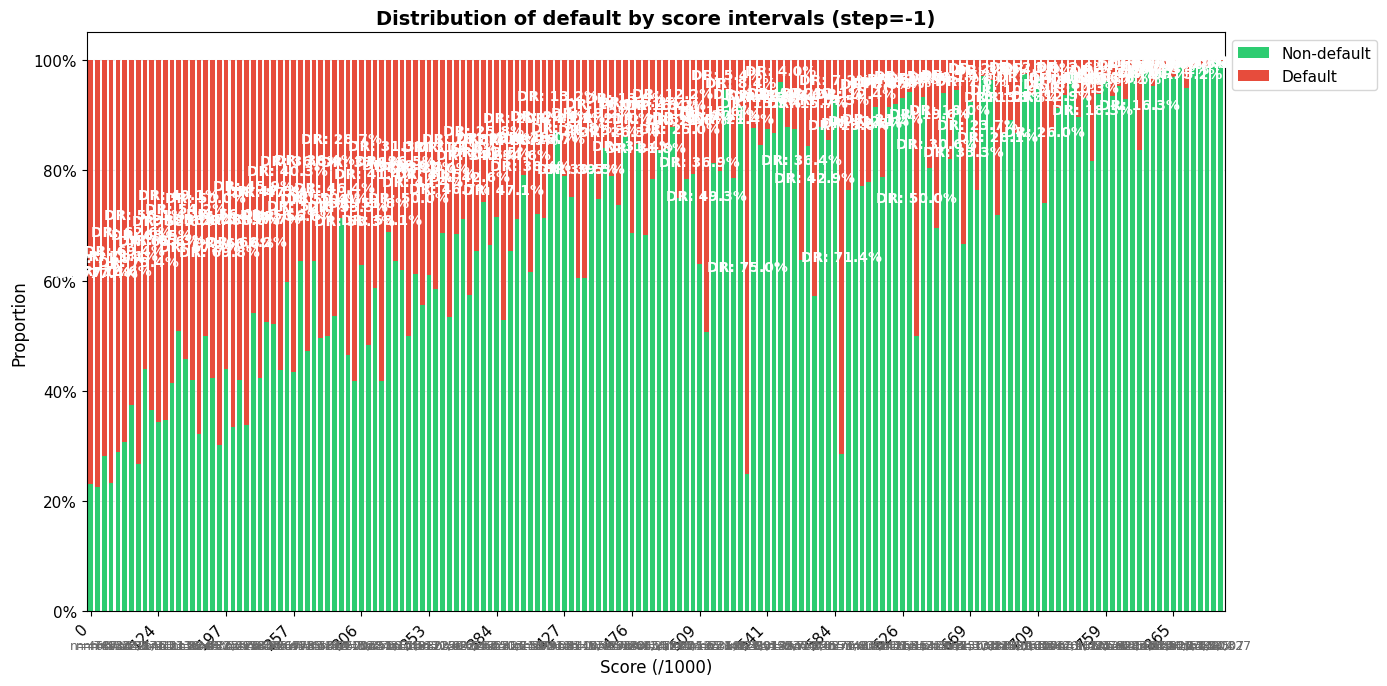


SUMMARY BY SCORE INTERVAL
      Score  Total  Non-default  Default Default Rate
   0.000000    460          106      354       76.96%
   9.969372    787          178      609       77.38%
  32.980970    491          138      353       71.89%
  50.344236    184           43      141       76.63%
  60.313608    304           88      216       71.05%
  74.534014    222           68      154       69.37%
  83.325206    211           79      132       62.56%
  84.503386    364           97      267       73.35%
 107.514983    271          119      152       56.09%
 118.485227   1941          708     1233       63.52%
 124.878250     61           21       40       65.57%
 134.847622    121           42       79       65.29%
 137.335473    111           46       65       58.56%
 147.304845    336          171      165       49.11%
 157.859219     96           44       52       54.17%
 168.829463    834          350      484       58.03%
 170.316443    248           80      168       67.74%
 

In [110]:
score_graph_empile(train_data, score_col='points', label_col=target_col, pas=-1)
#probas_graph_empile(train_data, score_col='points', label_col='default_t_plus_1', pas=0.05)

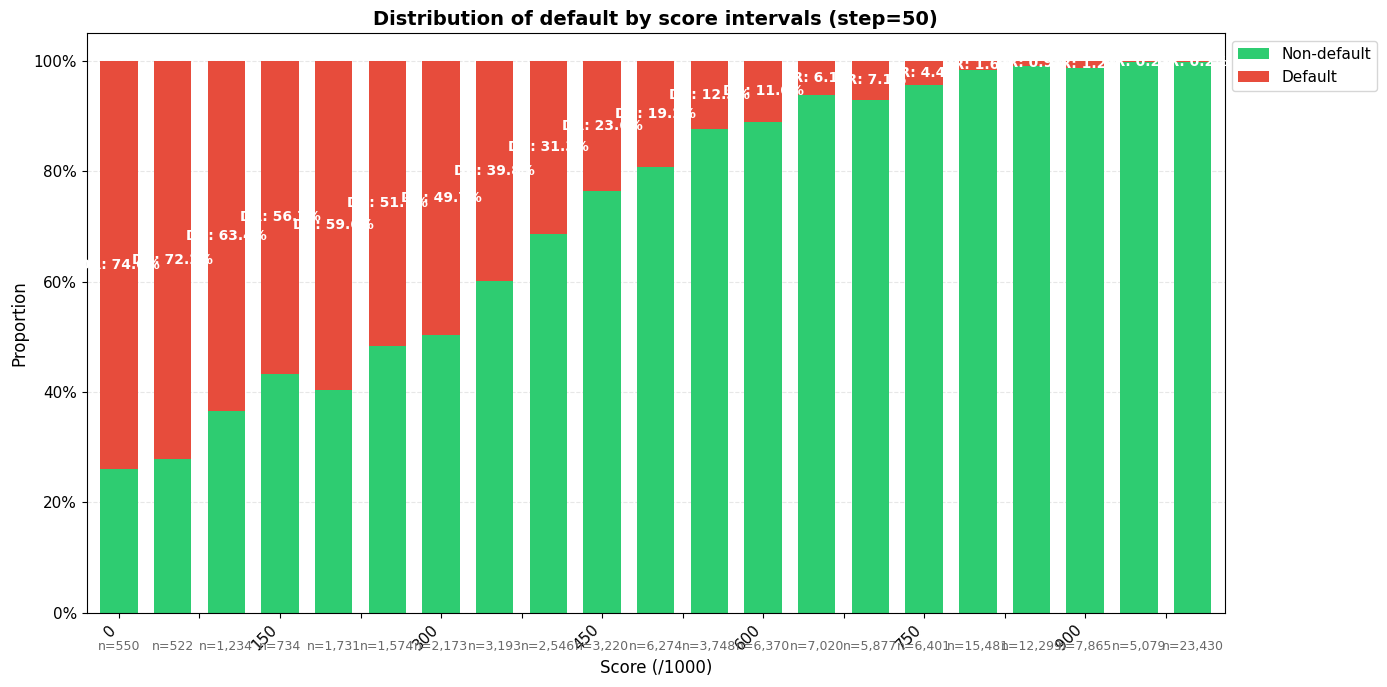


SUMMARY BY SCORE INTERVAL
 Score  Total  Non-default  Default Default Rate
     0    550          143      407       74.00%
    50    522          145      377       72.22%
   100   1234          452      782       63.37%
   150    734          318      416       56.68%
   200   1731          700     1031       59.56%
   250   1574          761      813       51.65%
   300   2173         1093     1080       49.70%
   350   3193         1922     1271       39.81%
   400   2546         1749      797       31.30%
   450   3220         2459      761       23.63%
   500   6274         5070     1204       19.19%
   550   3748         3287      461       12.30%
   600   6370         5669      701       11.00%
   650   7020         6590      430        6.13%
   700   5877         5460      417        7.10%
   750   6401         6121      280        4.37%
   800  15481        15240      241        1.56%
   850  12299        12189      110        0.89%
   900   7865         7767       98       

In [33]:
score_graph_empile(test_data, score_col='points', label_col=target_col, pas=50)


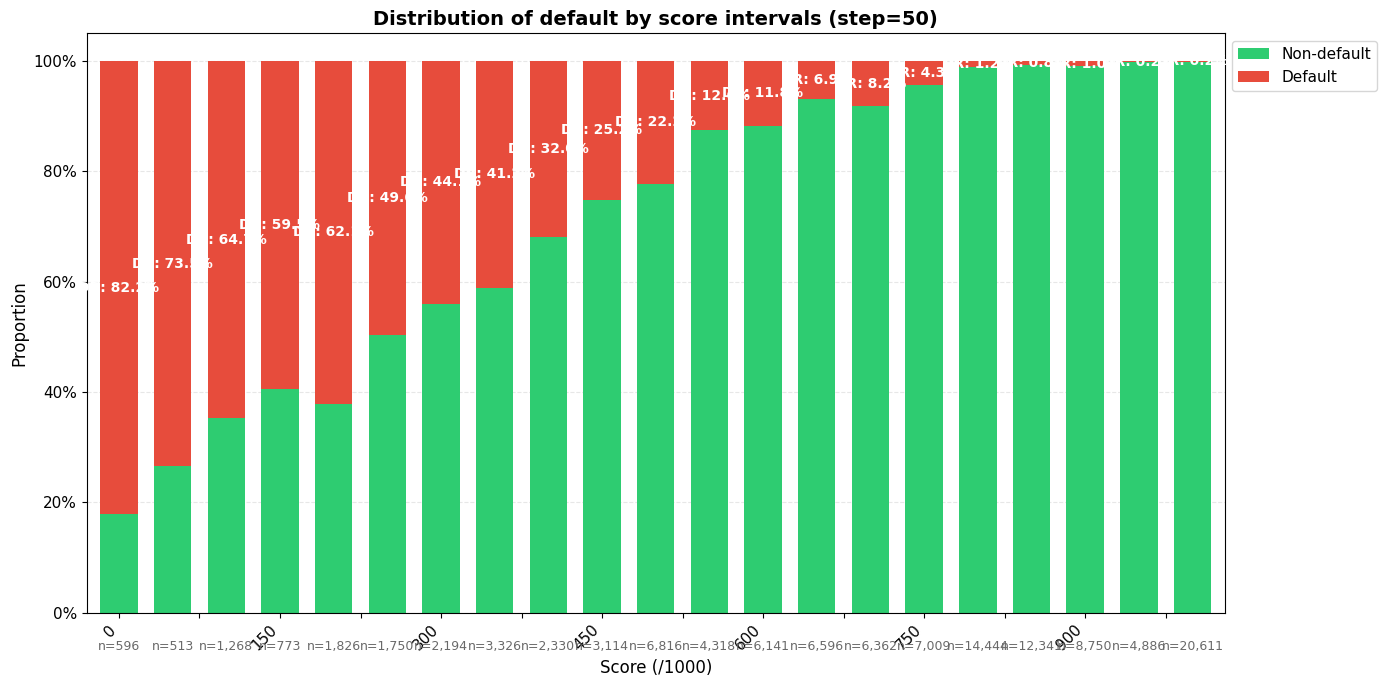


SUMMARY BY SCORE INTERVAL
 Score  Total  Non-default  Default Default Rate
     0    596          106      490       82.21%
    50    513          136      377       73.49%
   100   1268          447      821       64.75%
   150    773          313      460       59.51%
   200   1826          692     1134       62.10%
   250   1750          882      868       49.60%
   300   2194         1227      967       44.07%
   350   3326         1957     1369       41.16%
   400   2330         1585      745       31.97%
   450   3114         2329      785       25.21%
   500   6816         5300     1516       22.24%
   550   4318         3775      543       12.58%
   600   6141         5419      722       11.76%
   650   6596         6140      456        6.91%
   700   6362         5841      521        8.19%
   750   7009         6709      300        4.28%
   800  14444        14276      168        1.16%
   850  12341        12243       98        0.79%
   900   8750         8665       85       

In [34]:
score_graph_empile(oot_data, score_col='points', label_col=target_col, pas=50)


# Construction des CHR (stabilité en risque et volume)

## Useful objects

In [70]:
from src import binner
  # recharge le module avec les dernières modifications
reload(binner)
Binner = binner.Binner
cols = final_vars + ['month','probas',target_col,'points']
train_df = train_data[cols].copy()

test_df = test_data[cols].copy()
oot_df = oot_data[cols].copy()
Bin_train = Binner(X = train_df,cible_col=target_col,date_col='month')
Bin_test = Binner(X = test_df,cible_col=target_col,date_col='month')
Bin_oot = Binner(X = oot_df,cible_col=target_col,date_col='month')


In [57]:
def merge_modalities(bin_instance,mapping, col='CHR' ):
    bin_instance.merge_modalities(
        col=col,
        mapping=mapping
    )

def apply_breaks(bin_instance, breaks,var = 'CHR',upp=None,low=None):
    if var not in bin_instance.X.columns:
        bin_instance.X[var] = np.nan
    bin_instance.X[var] = bin_instance.X[var].astype(str)
    if low is not None and upp is not None:
        mask = (bin_instance.X['probas'] > low) & (bin_instance.X['probas'] <= upp)
    elif low is not None:
        mask = bin_instance.X['probas'] > low
    elif upp is not None:
        mask = bin_instance.X['probas'] <= upp
    else:
        mask = None
    if mask is not None:
        bin_instance.X.loc[mask,var] = pd.cut(
            bin_instance.X.loc[mask,'probas'],
            bins=breaks,
            include_lowest=True
        ).astype(str)
    else:
        bin_instance.X[var] = pd.cut(
            bin_instance.X['probas'],
            bins=breaks,
            include_lowest=True
        ).astype(str)

In [58]:
import pandas as pd
import numpy as np
import jenkspy

def jenks_prebinning(
    df,
    variable,
    target,
    n_bins=8,
    min_bin_pct=0.01
):
    """
    Jenks pre-binning for IRB (exploratory only)

    Parameters
    ----------
    df : DataFrame (TRAIN uniquement)
    variable : str, variable continue
    target : str, défaut (0/1)
    n_bins : int, nombre max de classes Jenks
    min_bin_pct : float, taille minimale d'un bin

    Returns
    -------
    df_bins : DataFrame avec stats par bin
    breaks : seuils Jenks
    """

    # Séparation missing / non-missing
    df_nm = df[[variable, target]].dropna()
    df_miss = df[df[variable].isna()]

    # Jenks sur non-missing uniquement
    values = df_nm[variable].values

    # Sécurité si peu de valeurs uniques
    n_bins_eff = min(n_bins, len(np.unique(values)) - 1)
    if n_bins_eff < 2:
        raise ValueError("Pas assez de valeurs uniques pour Jenks")

    breaks = jenkspy.jenks_breaks(values, n_classes=n_bins_eff)

    # Application des bins
    df_nm['bin_raw'] = pd.cut(
        df_nm[variable],
        bins=breaks,
        include_lowest=True
    )

    # Stats par bin
    bin_stats = (
        df_nm
        .groupby('bin_raw')[target]
        .agg(['count', 'sum'])
        .rename(columns={'count': 'n_obs', 'sum': 'defaults'})
    )

    bin_stats['dr'] = bin_stats['defaults'] / bin_stats['n_obs']
    bin_stats['pct_obs'] = bin_stats['n_obs'] / bin_stats['n_obs'].sum()

    # Flag bins trop petits
    bin_stats['small_bin_flag'] = bin_stats['pct_obs'] < min_bin_pct

    # Missing bin (séparé)
    if len(df_miss) > 0:
        miss_defaults = df_miss[target].sum()
        miss_n = len(df_miss)
        miss_dr = miss_defaults / miss_n

        bin_stats.loc['Missing', :] = [
            miss_n,
            miss_defaults,
            miss_dr,
            miss_n / len(df),
            False
        ]

    return bin_stats, breaks



## premier regroupement

In [109]:
desc , breaks = jenks_prebinning(df=train_df,
    variable='probas',target=target_col,n_bins=12,
    min_bin_pct=0.01)

In [60]:
desc

,n_obs,defaults,dr,pct_obs,small_bin_flag
bin_raw,,,,,
"(0.00554, 0.04]",165075,1910,0.011570,0.603016,False
"(0.04, 0.11]",45451,3556,0.078238,0.166032,False
"(0.11, 0.184]",21600,3720,0.172222,0.078904,False
"(0.184, 0.273]",9804,2474,0.252346,0.035814,False
"(0.273, 0.375]",10108,3664,0.362485,0.036924,False
"(0.375, 0.498]",7669,3472,0.452732,0.028015,False
"(0.498, 0.684]",8178,4651,0.568721,0.029874,False
"(0.684, 0.865]",5864,3960,0.675307,0.021421,False


In [71]:
apply_breaks(Bin_oot, breaks)
apply_breaks(Bin_test, breaks)
apply_breaks(Bin_train, breaks)

In [72]:
train_df.CHR.unique()

array(['(0.00554, 0.04]', '(0.11, 0.184]', '(0.04, 0.11]',
       '(0.375, 0.498]', '(0.684, 0.865]', '(0.184, 0.273]',
       '(0.273, 0.375]', '(0.498, 0.684]'], dtype=object)

In [ ]:
# mapping = {
#     '(0.273, 0.375]' : '(0.273, 0.498]',
#     '(0.375, 0.498]' : '(0.273, 0.498]',
#     '(0.11, 0.184]' : '(0.11, 0.273]',
#     '(0.184, 0.273]' : '(0.11, 0.273]',
#     '(0.273, 0.498]' : '(0.273, 0.684]',
#     '(0.498, 0.684]' : '(0.273, 0.684]',
# }
# merge_modalities(Bin_train, mapping)
# merge_modalities(Bin_test, mapping)
# merge_modalities(Bin_oot, mapping)

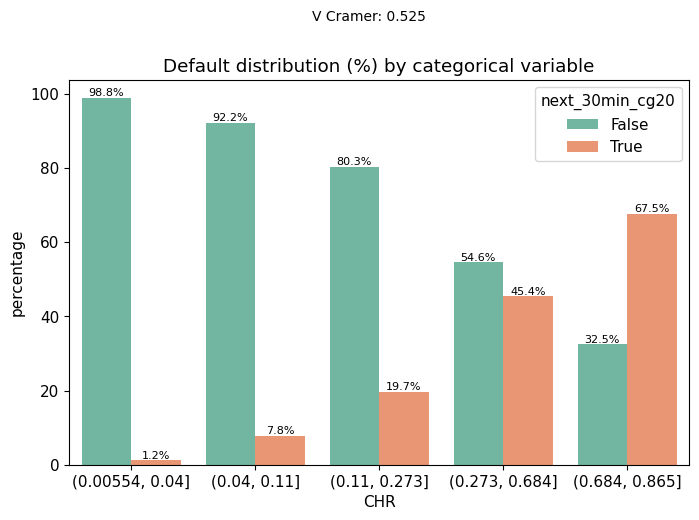

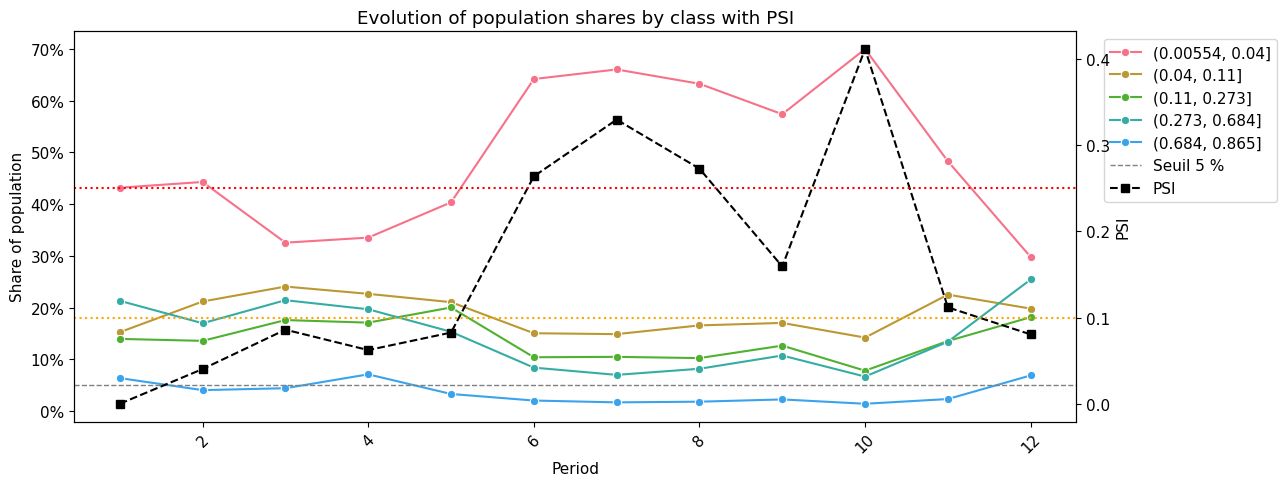

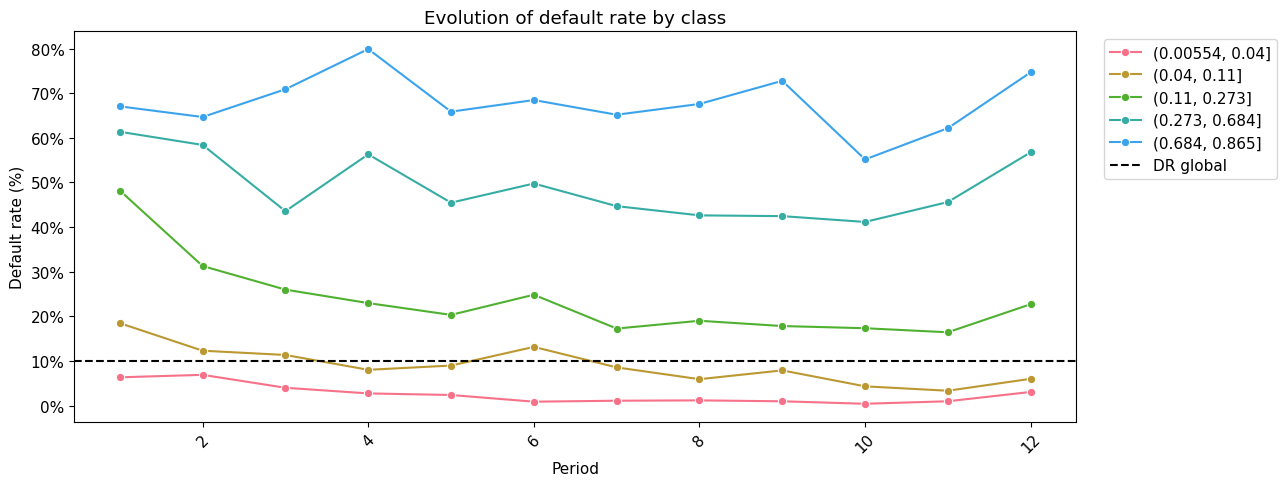

In [82]:
Bin_train.plot_categorical_distribution('CHR')
Bin_train.plot_bin_stability_over_time('CHR')

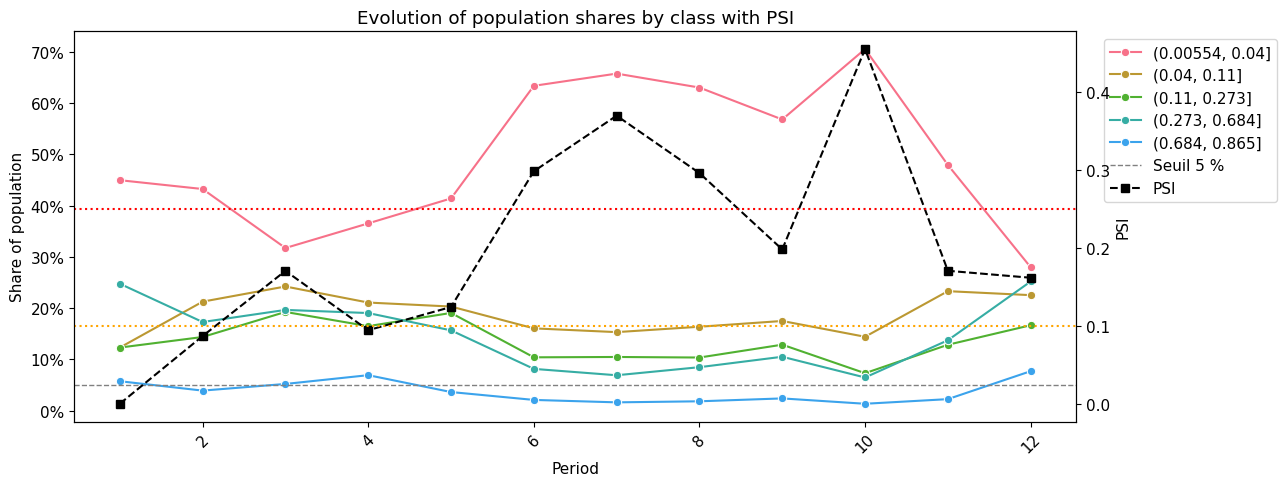

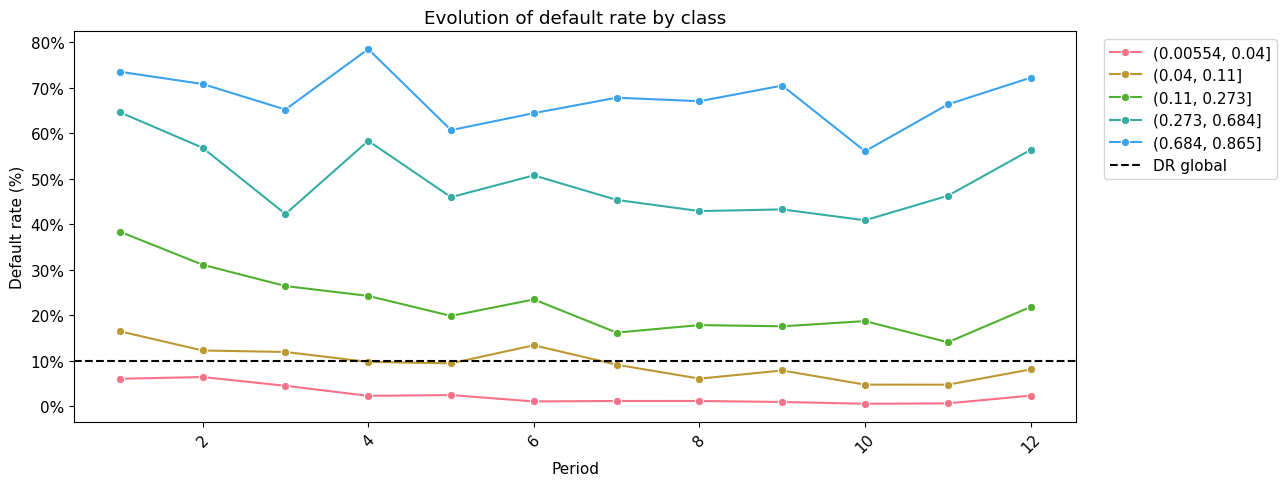

In [83]:
Bin_test.plot_bin_stability_over_time('CHR')

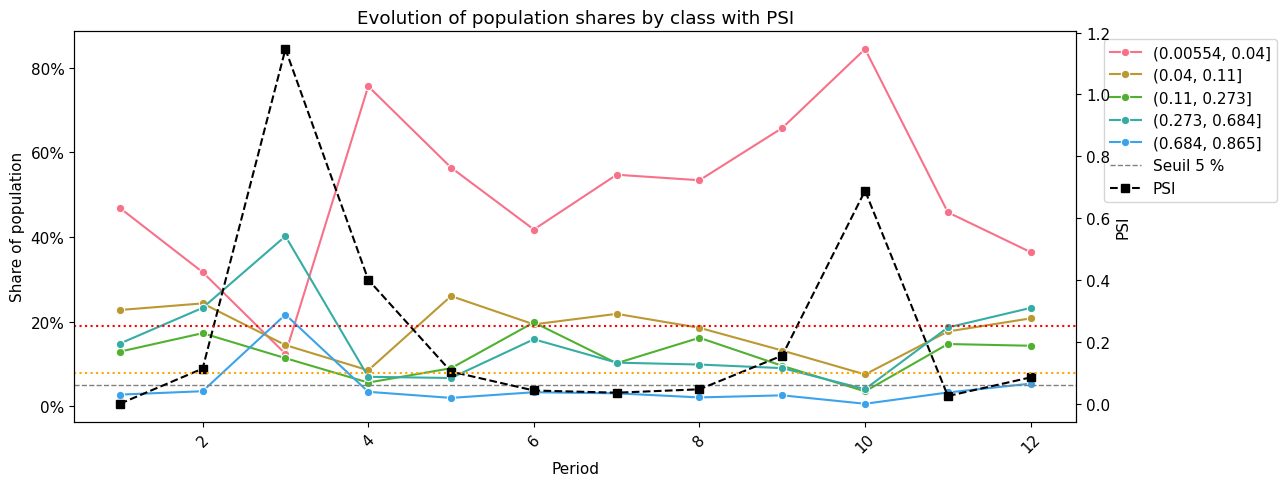

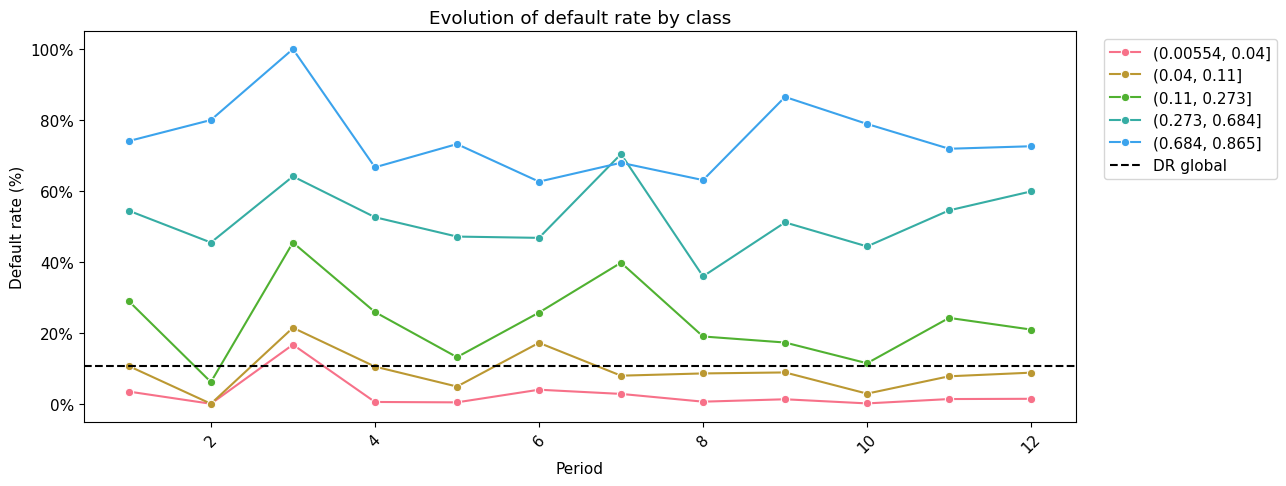

In [84]:
Bin_oot.plot_bin_stability_over_time('CHR')

In [85]:
train_df['CHR1'] = Bin_train.X['CHR']
test_df['CHR1'] = Bin_test.X['CHR']
oot_df['CHR1'] = Bin_oot.X['CHR']

## second regroupement

In [101]:
train_df['CHR'] = train_df['CHR1']
test_df['CHR'] = test_df['CHR1']
oot_df['CHR'] = oot_df['CHR1']

In [102]:
upp = train_df.loc[train_df['CHR'] == '(0.273, 0.684]','probas'].min()
mask = train_df['probas'] >= upp
desc , breaks = jenks_prebinning(df=train_df[mask],
    variable='probas',target=target_col,n_bins=6,
    min_bin_pct=0.01)

In [103]:
desc

,n_obs,defaults,dr,pct_obs,small_bin_flag
bin_raw,,,,,
"(0.283, 0.361]",8017,2845,0.354871,0.251956,False
"(0.361, 0.459]",8642,3790,0.438556,0.271599,False
"(0.459, 0.568]",4178,2046,0.489708,0.131305,False
"(0.568, 0.667]",5022,3054,0.608124,0.157830,False
"(0.667, 0.783]",3512,2185,0.622153,0.110374,False
"(0.783, 0.865]",2448,1827,0.746324,0.076935,False


In [104]:
upp

np.float64(0.2835571631687512)

In [105]:
apply_breaks(Bin_oot, breaks,upp = upp)
apply_breaks(Bin_test, breaks, upp = upp)
apply_breaks(Bin_train, breaks, upp = upp)

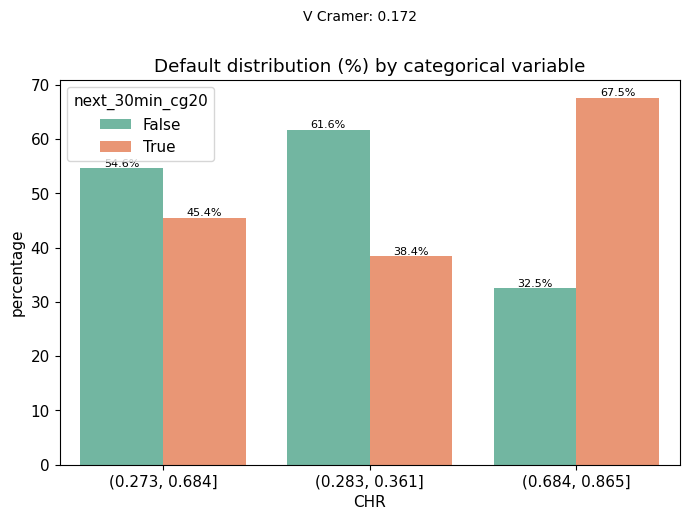

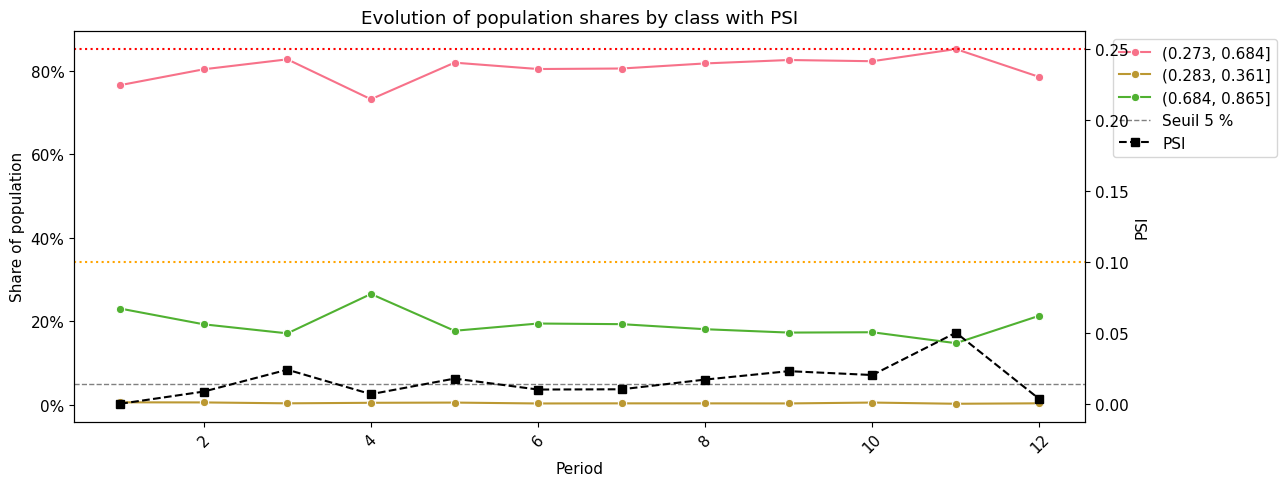

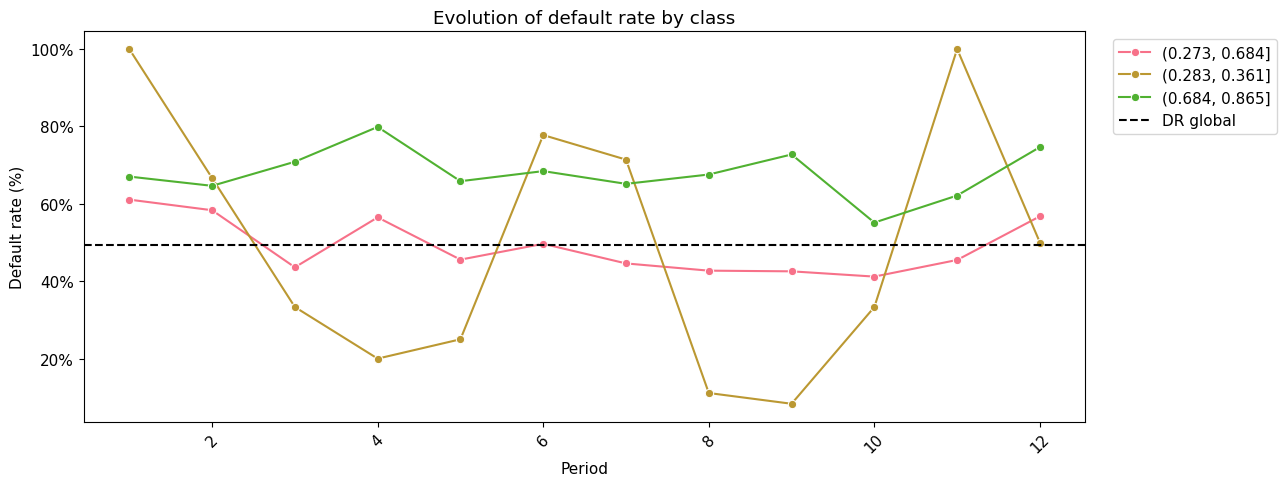

In [106]:
Bin_train.plot_categorical_distribution('CHR',mask=mask)
Bin_train.plot_bin_stability_over_time('CHR',mask=mask)

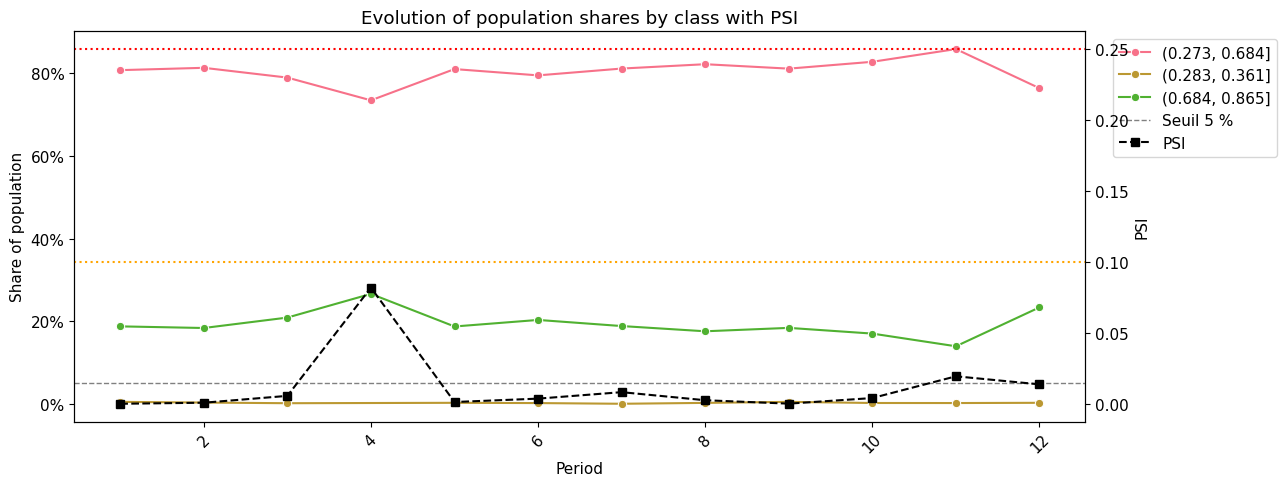

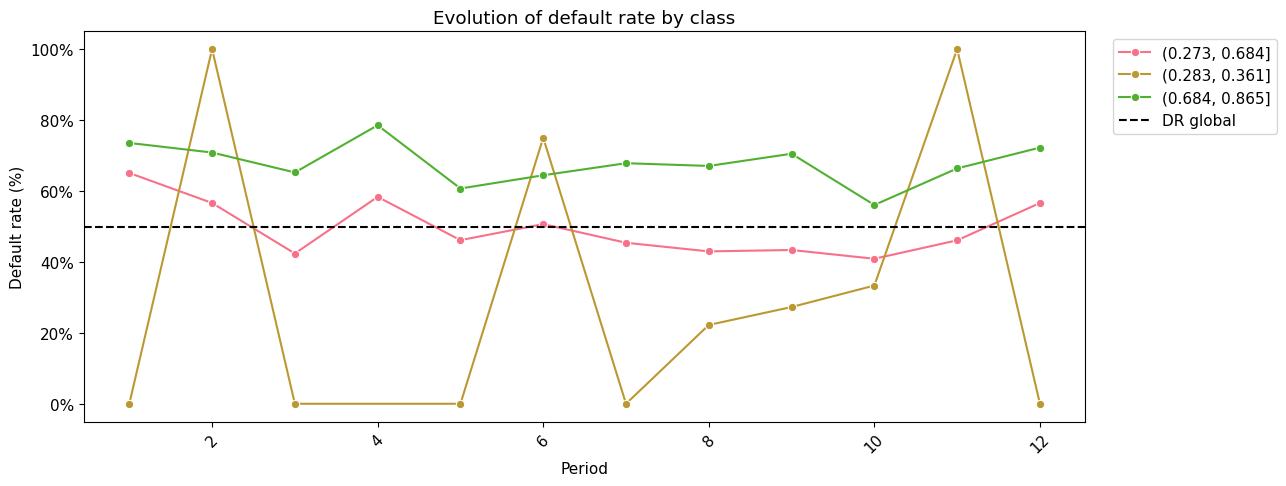

In [108]:
Bin_test.plot_bin_stability_over_time('CHR',mask=test_df['probas'] >= upp)

## CHR

In [86]:
train_df['CHR'] = Bin_train.X['CHR1']
test_df['CHR'] = Bin_test.X['CHR1']
oot_df['CHR'] = Bin_oot.X['CHR1']

In [87]:
bin_stats = (
    train_df
    .groupby('CHR')[[target_col,'probas', 'points']]
    .agg({
        target_col: ['count', 'sum'],
        'probas' : ['min', 'max'],
        'points': ['min', 'max']
    })
)

# Flatten MultiIndex columns
bin_stats.columns = ['n_obs', 'defaults','min_probas', 'max_probas', 'min_points', 'max_points']

bin_stats['dr'] = bin_stats['defaults'] / bin_stats['n_obs']
bin_stats['pct_obs'] = bin_stats['n_obs'] / bin_stats['n_obs'].sum()
bin_stats


,n_obs,defaults,min_probas,max_probas,min_points,max_points,dr,pct_obs
CHR,,,,,,,,
"(0.00554, 0.04]",165075,1910,0.006539,0.040025,731.707686,1000.000000,0.011570,0.603016
"(0.04, 0.11]",45451,3556,0.043357,0.109714,574.201465,719.580472,0.078238,0.166032
"(0.11, 0.273]",31404,6194,0.118278,0.273099,412.194564,561.873402,0.197236,0.114718
"(0.273, 0.684]",25955,11787,0.283557,0.683745,157.859219,404.626916,0.454132,0.094813
"(0.684, 0.865]",5864,3960,0.699235,0.864972,0.000000,147.304845,0.675307,0.021421


In [88]:
breaks = [bin_stats['min_probas'].min()] + bin_stats['max_probas'].to_list()
breaks

[np.float64(0.006538819529139699),
 0.04002461822217366,
 0.10971380353274092,
 0.27309917191176103,
 0.6837452486834181,
 0.8649715741114959]

# Prediction globale

In [89]:
# apply_breaks(Bin_oot, breaks)
# apply_breaks(Bin_test, breaks)
apply_breaks(Bin_train, breaks,var = "CHR3")
train_df.head()

,min_dist_10min,mean_azimuth_1min,time_since_last_cloud_ground2,dist,month,probas,next_30min_cg20,points,CHR,CHR1,CHR3
0,2.669325,262.242070,0.000000,24.066498,10,0.016109,False,867.556179,"(0.00554, 0.04]","(0.00554, 0.04]","(0.00554, 0.04]"
1,13.443093,86.676095,1.098612,23.832915,8,0.126161,False,551.189867,"(0.11, 0.273]","(0.11, 0.273]","(0.11, 0.273]"
2,1.925643,264.538685,0.000000,25.322532,10,0.016109,False,867.556179,"(0.00554, 0.04]","(0.00554, 0.04]","(0.00554, 0.04]"
3,1.485189,239.159969,3.091042,20.898251,7,0.016109,False,867.556179,"(0.00554, 0.04]","(0.00554, 0.04]","(0.00554, 0.04]"
4,13.277069,255.603448,0.000000,17.251821,8,0.026771,False,792.149543,"(0.00554, 0.04]","(0.00554, 0.04]","(0.00554, 0.04]"


In [90]:
dta = pred.prepare_data(data)
data['probas'] = pred.predire_probas(dta)
data['points'] = pred.predire_points1000(dta)
data['CHR'] = pd.cut(
        data['probas'],
        bins=breaks,
        include_lowest=True
        ).astype(str)

In [91]:
data['CHR'].unique()

array(['(0.273, 0.684]', '(0.11, 0.273]', '(0.04, 0.11]',
       '(0.684, 0.865]', '(0.00554, 0.04]'], dtype=object)

In [67]:
dic = {
    '(0.009399999999999999, 0.0302]' : 'AA',
    '(0.0302, 0.0576]' : 'A',
    '(0.0576, 0.107]' : 'BB',
    '(0.107, 0.369]' : 'B',
    '(0.369, 0.533]' : 'C',
}
data['class'] = data['CHR'].map(dic)

# Evolution des CHR

<Axes: xlabel='month'>

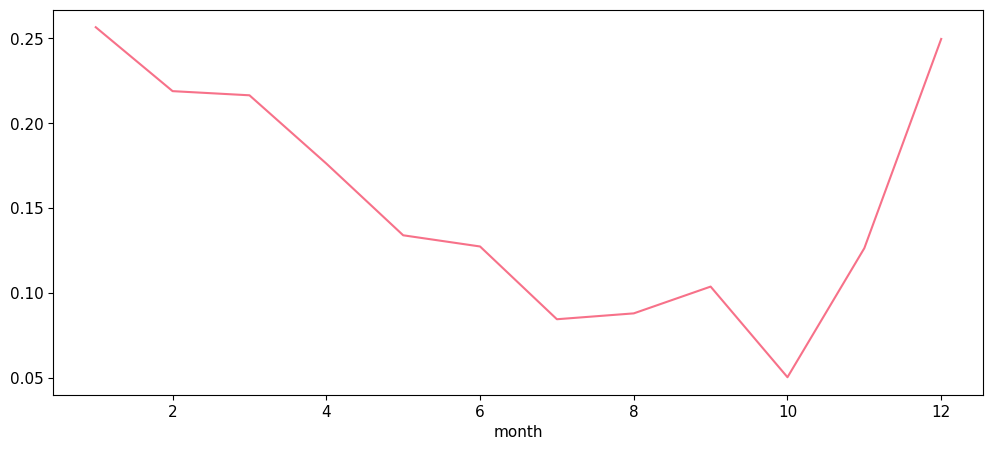

In [94]:
data.groupby('month')[target_col].mean().plot()

In [95]:
Bin_data = Binner(X = data,cible_col=target_col,date_col='month')

In [ ]:
# mapping = {
#     '(0.009399999999999999, 0.0302]' : '(0.0093, 0.0302]',
# }
# merge_modalities(Bin_data, mapping)

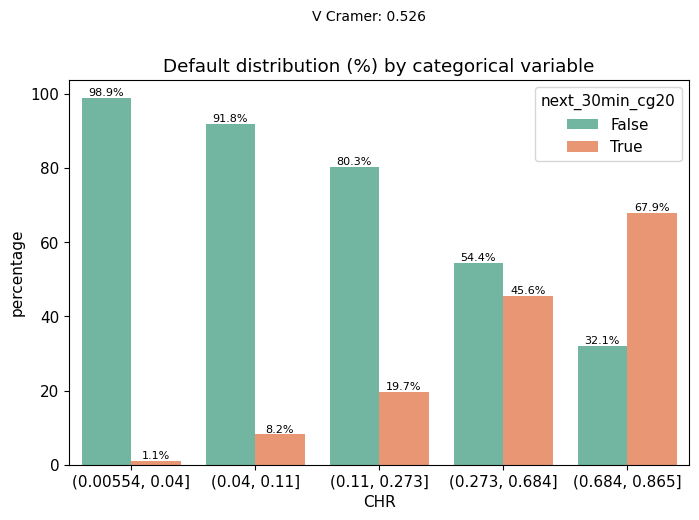

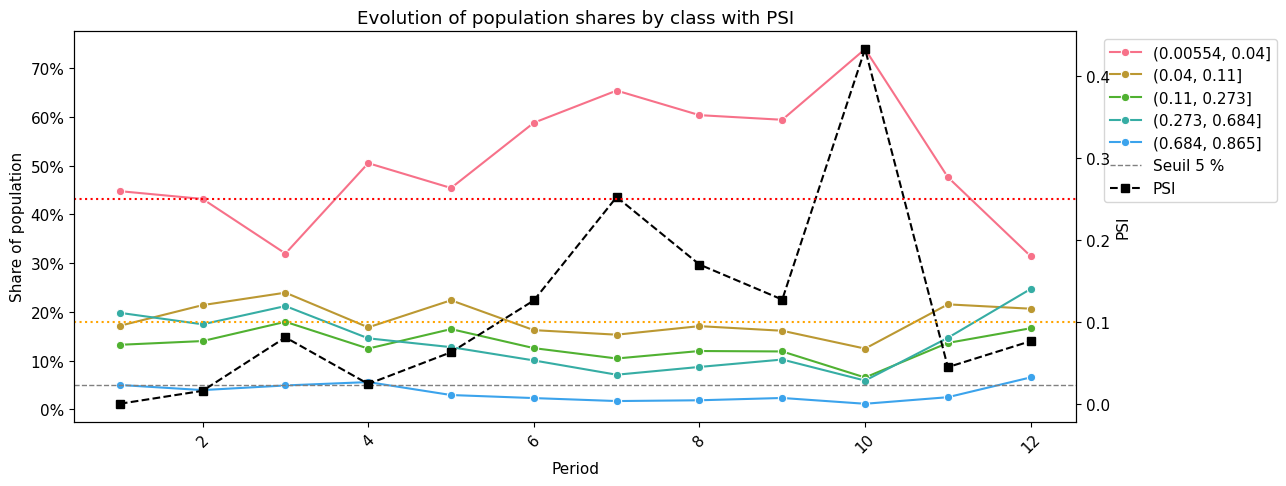

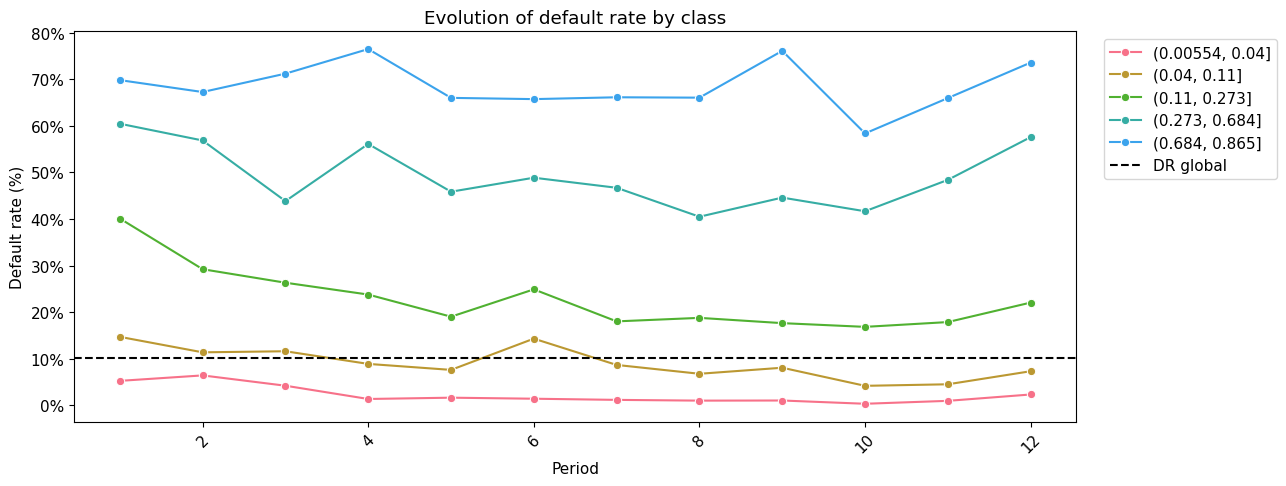

In [97]:
Bin_data.plot_categorical_distribution('CHR')
Bin_data.plot_bin_stability_over_time('CHR')

# LRA

In [99]:
mean_by_class = (
    data
    .groupby(['CHR'])[target_col]
    .mean()
)
mean_by_class


CHR
(0.00554, 0.04]    0.011213
(0.04, 0.11]       0.081618
(0.11, 0.273]      0.197457
(0.273, 0.684]     0.456146
(0.684, 0.865]     0.679435
Name: next_30min_cg20, dtype: float64

In [100]:
CHR_dic = {classe: float(mean_by_class[classe]) for classe in mean_by_class.index}
data['LRA'] = data['CHR'].map(CHR_dic)

In [ ]:
# data.to_csv('..\data\pd_dataset_with_missing_pred2.csv', index=False)
# data_complete.to_csv('..\data\pd_dataset_complete_pred2.csv',index=False)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\UltraBook 3.1\AppData\Local\Temp\ipykernel_26176\1314383956.py:1: SyntaxWarning: invalid escape sequence '\d'
  data.to_csv('..\data\pd_dataset_with_missing_pred2.csv', index=False)
C:\Users\UltraBook 3.1\AppData\Local\Temp\ipykernel_26176\1314383956.py:2: SyntaxWarning: invalid escape sequence '\d'
  data_complete.to_csv('..\data\pd_dataset_complete_pred2.csv',index=False)
